<a href="https://colab.research.google.com/github/Tulin206/erumhub_deep-learning_2026/blob/main/code/07_Monitor_Training_Weather_Regression_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting the Sunshine Hours Tomorrow

A regression task on the weather prediction dataset


In [ ]:
# Import pandas for data manipulation
import pandas as pd

# Load the weather prediction dataset from a remote CSV file
df = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset.csv")

# Display summary statistics of the dataframe
df.describe()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
count,3.654000e+03,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,...,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000
mean,2.004568e+07,6.520799,5.418446,0.745107,1.017876,1.330380,0.234849,4.661193,11.022797,6.989135,...,5.104215,11.470635,3.677258,0.781872,1.016639,1.369787,0.186100,12.205802,7.860536,16.551779
std,2.874287e+04,3.450083,2.325497,0.107788,0.007962,0.935348,0.536267,4.330112,7.414754,6.653356,...,7.250744,8.950217,1.519866,0.115572,0.018885,0.926472,0.422151,6.467155,5.692256,7.714924
min,2.000010e+07,1.000000,0.000000,0.380000,0.985600,0.050000,0.000000,0.000000,-9.300000,-16.000000,...,-19.700000,-14.500000,0.700000,0.330000,0.000300,0.050000,0.000000,-6.200000,-13.000000,-3.100000
25%,2.002070e+07,4.000000,4.000000,0.670000,1.013300,0.530000,0.000000,0.500000,5.300000,2.000000,...,0.000000,4.100000,2.600000,0.700000,1.012100,0.550000,0.000000,7.600000,3.700000,10.800000
50%,2.004567e+07,7.000000,6.000000,0.760000,1.017700,1.110000,0.000000,3.600000,11.400000,7.300000,...,5.000000,11.000000,3.400000,0.800000,1.017300,1.235000,0.000000,12.300000,8.300000,16.600000
75%,2.007070e+07,10.000000,7.000000,0.830000,1.022700,2.060000,0.210000,8.000000,16.900000,12.400000,...,11.200000,19.000000,4.600000,0.870000,1.022200,2.090000,0.160000,17.200000,12.300000,22.400000
max,2.010010e+07,12.000000,8.000000,0.980000,1.040800,3.550000,7.570000,15.300000,29.000000,20.800000,...,21.200000,32.900000,10.800000,1.000000,1.041400,3.560000,6.200000,31.200000,22.600000,39.800000


In [ ]:
# Show the shape (rows, columns) of the dataframe
df.shape

(3654, 165)

In [ ]:
# List all column names in the dataframe
df.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min',
       ...
       'STOCKHOLM_temp_min', 'STOCKHOLM_temp_max', 'TOURS_wind_speed',
       'TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation',
       'TOURS_precipitation', 'TOURS_temp_mean', 'TOURS_temp_min',
       'TOURS_temp_max'],
      dtype='object', length=165)

In [ ]:
# Print the set of unique suffixes in column names (excluding 'MONTH' and 'DATE')
print(set({ "_".join(x.split("_")[1:]) for x in df.columns if x not in ["MONTH", "DATE"]  }))

{'sunshine', 'BILT_wind_gust', 'wind_gust', 'global_radiation', 'wind_speed', 'precipitation', 'BILT_pressure', 'temp_mean', 'temp_min', 'BILT_sunshine', 'pressure', 'BILT_temp_min', 'cloud_cover', 'BILT_temp_max', 'BILT_cloud_cover', 'BILT_wind_speed', 'BILT_humidity', 'BILT_precipitation', 'humidity', 'temp_max', 'BILT_global_radiation', 'BILT_temp_mean'}


In [ ]:
# Set the number of rows to use (3 years of daily data)
nr_rows = 365*3

# Select the feature columns, dropping 'DATE' and 'MONTH'
X_data = df.loc[:nr_rows].drop(columns=["DATE", "MONTH"])

In [ ]:
# Show the shape of the feature matrix
X_data.shape

(1096, 163)

In [ ]:
# Print all column names that contain 'BASEL'
print([ item for item in df.columns if "BASEL" in item])

['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max']


In [ ]:
# Select the target variable: next day's sunshine hours in Basel
y_data = df.loc[1:(nr_rows+1)]["BASEL_sunshine"]

In [ ]:
# Show the data type of the target variable
y_data.dtype

dtype('float64')

In [ ]:
# Import train_test_split for splitting data into train/validation/test
from sklearn.model_selection import train_test_split

# Split the data into training and not-training sets (70% train, 30% not-train)
X_train, X_not_train, y_train, y_not_train = train_test_split(X_data, y_data, test_size=.3, random_state=20211013)

In [ ]:
# Split the not-training set into validation and test sets (each 15% of total)
X_val, X_test, y_val, y_test = train_test_split(X_not_train, y_not_train, test_size=.5, random_state=20211014)


In [ ]:
# Print the shape of the training feature matrix
print(X_train.shape)

(767, 163)


In [ ]:
# Print the shapes of the test and validation feature matrices
print(X_test.shape, X_val.shape)

(165, 163) (164, 163)


In [ ]:
# Import keras for building neural networks
from tensorflow import keras

# Define a function to create a neural network model
def create_nn():
    # Define the input layer with the correct number of features
    inputs = keras.Input(shape=(X_data.shape[1],), name="input")
    # Add a dense hidden layer with 100 units and ReLU activation
    dense1 = keras.layers.Dense(100, 'relu', name="dense1")(inputs)
    # Add a second dense hidden layer with 50 units and ReLU activation
    dense2 = keras.layers.Dense(50, 'relu', name="dense2")(dense1)
    # Add the output layer with 1 unit (regression output)
    outputs = keras.layers.Dense(1)(dense2)
    # Return the constructed model
    return keras.Model(inputs=inputs, outputs=outputs, name="weather_prediction_model")

In [ ]:
# Create the neural network model
model = create_nn()
# Display the model architecture
model.summary()

Model: "weather_prediction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 163)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 100)            │        16,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,501 (83.99 KB)

 Trainable params: 21,501 (83.99 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model with Adam optimizer, mean squared error loss, and RMSE metric
model.compile(optimizer="adam",
              loss="mse", #MEAN SQUARED ERROR
              metrics=[keras.metrics.RootMeanSquaredError()])


In [ ]:
# Train the model on the training data for 200 epochs
history = model.fit(X_train, y_train,
                    batch_size = 32,
                    epochs=200,
                    verbose=2
                    )

Epoch 1/200
24/24 - 1s - 32ms/step - loss: 29.1139 - root_mean_squared_error: 5.3957
Epoch 2/200
24/24 - 0s - 2ms/step - loss: 13.5082 - root_mean_squared_error: 3.6754
Epoch 3/200
24/24 - 0s - 2ms/step - loss: 12.8037 - root_mean_squared_error: 3.5782
Epoch 4/200
24/24 - 0s - 2ms/step - loss: 11.5943 - root_mean_squared_error: 3.4050
Epoch 5/200
24/24 - 0s - 3ms/step - loss: 11.5417 - root_mean_squared_error: 3.3973
Epoch 6/200
24/24 - 0s - 2ms/step - loss: 10.8903 - root_mean_squared_error: 3.3000
Epoch 7/200
24/24 - 0s - 3ms/step - loss: 10.7787 - root_mean_squared_error: 3.2831
Epoch 8/200
24/24 - 0s - 3ms/step - loss: 11.0992 - root_mean_squared_error: 3.3315
Epoch 9/200
24/24 - 0s - 3ms/step - loss: 9.6847 - root_mean_squared_error: 3.1120
Epoch 10/200
24/24 - 0s - 3ms/step - loss: 10.2286 - root_mean_squared_error: 3.1982
Epoch 11/200
24/24 - 0s - 2ms/step - loss: 10.3416 - root_mean_squared_error: 3.2158
Epoch 12/200
24/24 - 0s - 3ms/step - loss: 10.3849 - root_mean_squared_err

In [ ]:
# Import seaborn and matplotlib for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the training history to a DataFrame for analysis
history_df = pd.DataFrame.from_dict(history.history)


In [ ]:
# List all columns in the history DataFrame
history_df.columns

Index(['loss', 'root_mean_squared_error'], dtype='object')

Text(0, 0.5, 'RMSE')

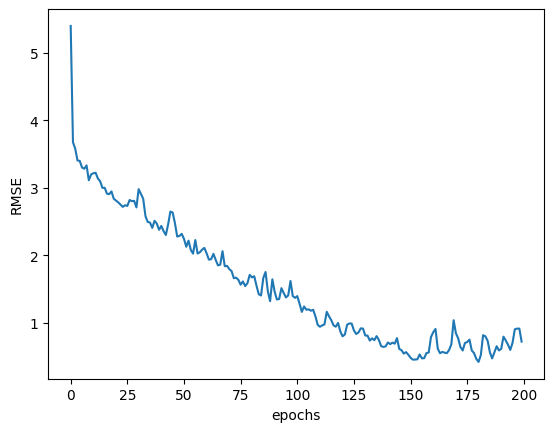

In [ ]:
# Plot the RMSE on the training data over epochs
sns.lineplot(data=history_df['root_mean_squared_error'])
plt.xlabel("epochs")
plt.ylabel("RMSE")

In [ ]:
# Make predictions on the training and test sets
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Text(0, 0.5, 'true sunshine hours')

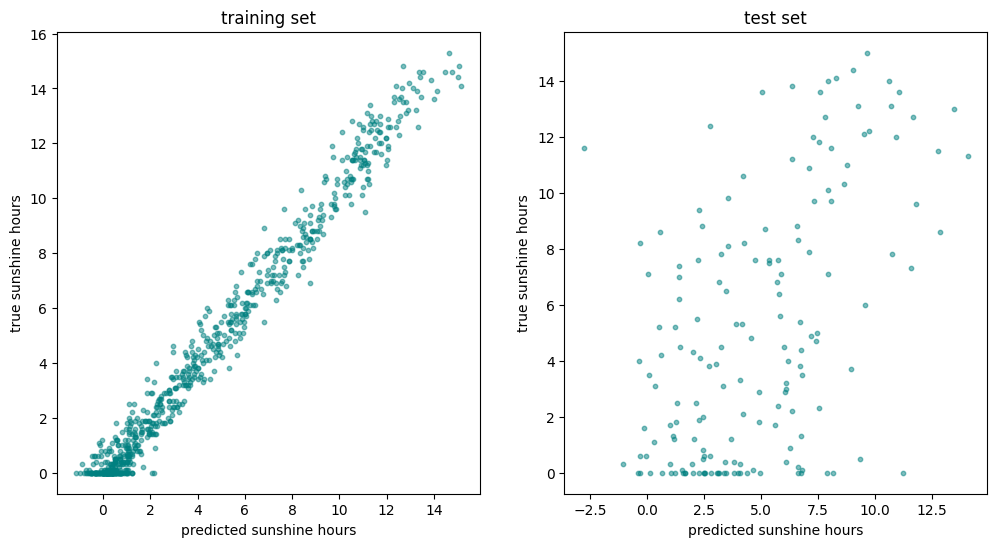

In [ ]:
# Create scatter plots to compare predicted and true sunshine hours
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(y_train_predict, y_train, s=10, alpha=0.5, color="teal")
axes[0].set_title("training set")
axes[0].set_xlabel("predicted sunshine hours")
axes[0].set_ylabel("true sunshine hours")

axes[1].scatter(y_test_predict, y_test, s=10, alpha=0.5, color="teal")
axes[1].set_title("test set")
axes[1].set_xlabel("predicted sunshine hours")
axes[1].set_ylabel("true sunshine hours")


In [ ]:
# Evaluate the model performance on the training and test sets
loss_train, rmse_train = model.evaluate(X_train, y_train)
loss_test, rmse_test = model.evaluate(X_test, y_test)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4369 - root_mean_squared_error: 0.6610 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.1315 - root_mean_squared_error: 4.0164 


In [ ]:
# Print the RMSE for the training and test sets
print("training set",rmse_train)
print("    test set",rmse_test)


training set 0.6609540581703186
    test set 4.016404628753662


# Yikes Overfitting !

## Set expectations: How difficult is the defined problem?

Text(0, 0.5, 'true sunshine hours')

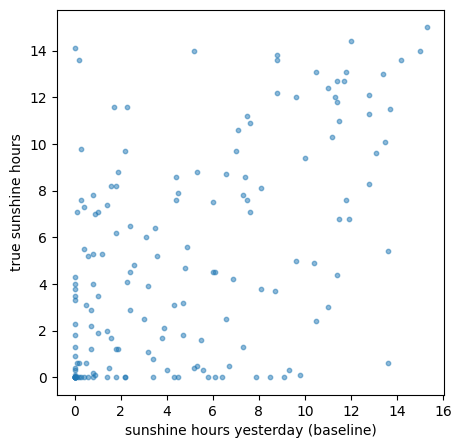

In [ ]:
# Use yesterday's sunshine hours as a simple baseline predictor
y_baseline_prediction = X_test["BASEL_sunshine"]

plt.figure(figsize=(5,5), dpi=100)
plt.scatter(y_baseline_prediction, y_test, s=10, alpha=.5)
plt.xlabel("sunshine hours yesterday (baseline)")
plt.ylabel("true sunshine hours")


In [ ]:
# Import mean_squared_error for performance comparison
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate the RMSE of the neural network predictions
rmse_nn = np.sqrt(mean_squared_error(y_test, y_test_predict))

# Calculate the RMSE of the baseline predictions
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_baseline_prediction))

In [ ]:
# Print the RMSE for the neural network and baseline models
print("training set",rmse_nn)
print("baseline set",rmse_baseline)

training set 4.016404831450722
baseline set 4.354217739297396


In [ ]:
# Recreate and compile the neural network model
model = create_nn()
model.compile(optimizer='adam',
              loss='mse',
              metrics=[keras.metrics.RootMeanSquaredError()])

In [ ]:
# Train the model on the training data for 200 epochs, with validation on the validation set
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=200,
                    validation_data=(X_val, y_val),
                    verbose=2)

Epoch 1/200
24/24 - 1s - 52ms/step - loss: 25.3595 - root_mean_squared_error: 5.0358 - val_loss: 17.6295 - val_root_mean_squared_error: 4.1988
Epoch 2/200
24/24 - 0s - 6ms/step - loss: 13.9105 - root_mean_squared_error: 3.7297 - val_loss: 15.3440 - val_root_mean_squared_error: 3.9171
Epoch 3/200
24/24 - 0s - 5ms/step - loss: 13.4593 - root_mean_squared_error: 3.6687 - val_loss: 13.7200 - val_root_mean_squared_error: 3.7041
Epoch 4/200
24/24 - 0s - 5ms/step - loss: 11.8911 - root_mean_squared_error: 3.4483 - val_loss: 12.9929 - val_root_mean_squared_error: 3.6046
Epoch 5/200
24/24 - 0s - 5ms/step - loss: 12.2032 - root_mean_squared_error: 3.4933 - val_loss: 12.4382 - val_root_mean_squared_error: 3.5268
Epoch 6/200
24/24 - 0s - 5ms/step - loss: 11.3212 - root_mean_squared_error: 3.3647 - val_loss: 11.9518 - val_root_mean_squared_error: 3.4571
Epoch 7/200
24/24 - 0s - 5ms/step - loss: 10.3614 - root_mean_squared_error: 3.2189 - val_loss: 11.3958 - val_root_mean_squared_error: 3.3758
Epoch

Text(0, 0.5, 'RMSE')

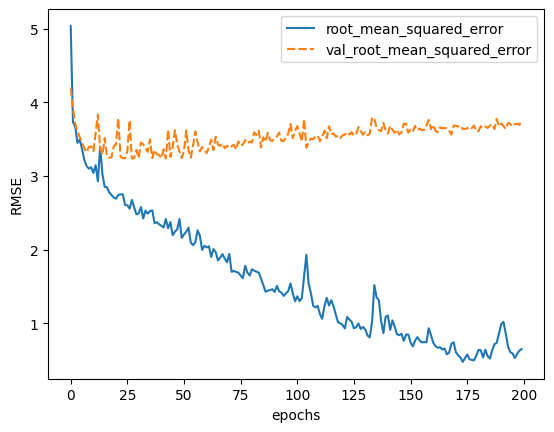

In [ ]:
# Convert the training history to a DataFrame for analysis
history_df = pd.DataFrame.from_dict(history.history)

# Plot the RMSE on the training and validation data over epochs
sns.lineplot(data=history_df[['root_mean_squared_error','val_root_mean_squared_error']])
plt.xlabel("epochs")
plt.ylabel("RMSE")

## Counteract model overfitting

reduce the number of parameters of our model

In [ ]:
# Define a new create_nn function that takes the number of nodes as arguments
def create_nn(nodes1, nodes2):
    # Define the input layer with the correct number of features
    inputs = keras.Input(shape=(X_data.shape[1],), name="input")
    # Add a dense hidden layer with nodes1 units and ReLU activation
    dense1 = keras.layers.Dense(nodes1, 'relu', name="dense1")(inputs)
    # Add a second dense hidden layer with nodes2 units and ReLU activation
    dense2 = keras.layers.Dense(nodes2, 'relu', name="dense2")(dense1)
    # Add the output layer with 1 unit (regression output)
    outputs = keras.layers.Dense(1)(dense2)
    # Return the constructed model
    return keras.Model(inputs=inputs, outputs=outputs, name="weather_prediction_model")

In [ ]:
# Create a smaller neural network model with 10 and 5 nodes in the hidden layers
model = create_nn(10,5)
# Display the model architecture
model.summary()

Model: "weather_prediction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 163)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 10)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701 (6.64 KB)

 Trainable params: 1,701 (6.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
24/24 - 1s - 48ms/step - loss: 41.2578 - root_mean_squared_error: 6.4232 - val_loss: 24.0737 - val_root_mean_squared_error: 4.9065
Epoch 2/200
24/24 - 0s - 8ms/step - loss: 21.6958 - root_mean_squared_error: 4.6579 - val_loss: 18.9833 - val_root_mean_squared_error: 4.3570
Epoch 3/200
24/24 - 0s - 7ms/step - loss: 18.1587 - root_mean_squared_error: 4.2613 - val_loss: 16.6947 - val_root_mean_squared_error: 4.0859
Epoch 4/200
24/24 - 0s - 9ms/step - loss: 16.5094 - root_mean_squared_error: 4.0632 - val_loss: 15.4040 - val_root_mean_squared_error: 3.9248
Epoch 5/200
24/24 - 0s - 9ms/step - loss: 15.4685 - root_mean_squared_error: 3.9330 - val_loss: 14.4564 - val_root_mean_squared_error: 3.8022
Epoch 6/200
24/24 - 0s - 8ms/step - loss: 15.1792 - root_mean_squared_error: 3.8960 - val_loss: 14.5797 - val_root_mean_squared_error: 3.8183
Epoch 7/200
24/24 - 0s - 4ms/step - loss: 14.0083 - root_mean_squared_error: 3.7428 - val_loss: 13.7557 - val_root_mean_squared_error: 3.7089
Epoch

Text(0, 0.5, 'RMSE')

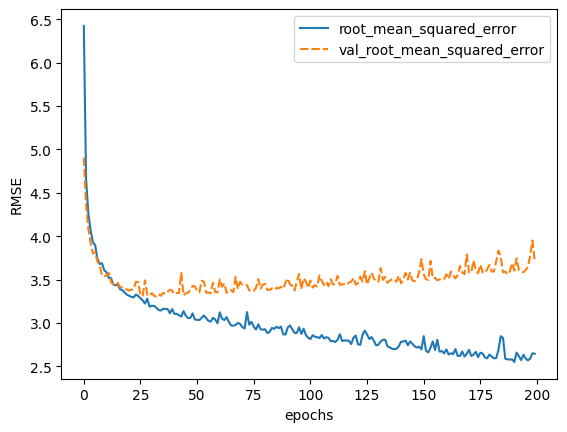

In [ ]:
# Compile the model with Adam optimizer, mean squared error loss, and RMSE metric
model.compile(optimizer='adam',
              loss='mse',
              metrics=[keras.metrics.RootMeanSquaredError()])

# Train the model on the training data for 200 epochs, with validation on the validation set
history = model.fit(X_train, y_train,
                    batch_size = 32,
                    epochs = 200,
                    validation_data=(X_val, y_val),
                    verbose = 2)

# Convert the training history to a DataFrame for analysis
history_df = pd.DataFrame.from_dict(history.history)

# Plot the RMSE on the training and validation data over epochs
sns.lineplot(data=history_df[['root_mean_squared_error', 'val_root_mean_squared_error']])
plt.xlabel("epochs")
plt.ylabel("RMSE")



In [ ]:
# Create a larger neural network model with 100 and 50 nodes in the hidden layers
model = create_nn(100, 50)
# Compile the model with Adam optimizer, mean squared error loss, and RMSE metric
model.compile(optimizer='adam',
              loss='mse',
              metrics=[keras.metrics.RootMeanSquaredError()])


In [ ]:
# Import EarlyStopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

# Set up EarlyStopping to monitor validation loss and stop training if it doesn't improve for 10 epochs
earlystop = EarlyStopping(monitor='val_loss',
                          patience=10,verbose=1)

# Train the model on the training data for 200 epochs, with validation on the validation set
# EarlyStopping will halt training early if there's no improvement
history = model.fit(X_train, y_train,
                    batch_size = 32,
                    epochs=200,
                    validation_data=(X_val, y_val),
                    callbacks=[earlystop],
                    verbose=2)

Epoch 1/200
24/24 - 1s - 39ms/step - loss: 16.9750 - root_mean_squared_error: 4.1201 - val_loss: 13.6764 - val_root_mean_squared_error: 3.6982
Epoch 2/200
24/24 - 0s - 5ms/step - loss: 12.1199 - root_mean_squared_error: 3.4814 - val_loss: 12.2594 - val_root_mean_squared_error: 3.5013
Epoch 3/200
24/24 - 0s - 5ms/step - loss: 11.6609 - root_mean_squared_error: 3.4148 - val_loss: 14.0454 - val_root_mean_squared_error: 3.7477
Epoch 4/200
24/24 - 0s - 5ms/step - loss: 11.4178 - root_mean_squared_error: 3.3790 - val_loss: 17.6049 - val_root_mean_squared_error: 4.1958
Epoch 5/200
24/24 - 0s - 6ms/step - loss: 10.7206 - root_mean_squared_error: 3.2742 - val_loss: 11.6605 - val_root_mean_squared_error: 3.4147
Epoch 6/200
24/24 - 0s - 5ms/step - loss: 10.1549 - root_mean_squared_error: 3.1867 - val_loss: 11.7988 - val_root_mean_squared_error: 3.4349
Epoch 7/200
24/24 - 0s - 5ms/step - loss: 9.7997 - root_mean_squared_error: 3.1305 - val_loss: 13.0379 - val_root_mean_squared_error: 3.6108
Epoch 

Text(0, 0.5, 'RMSE')

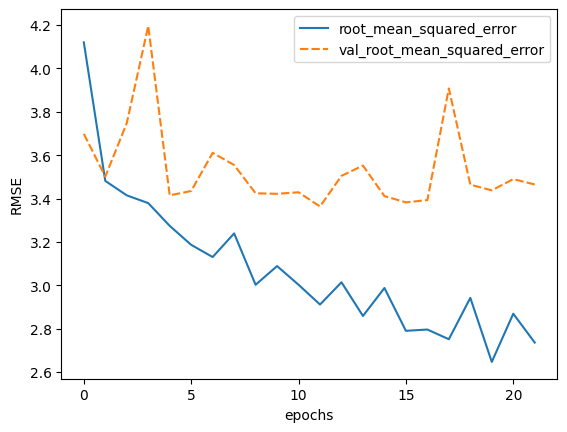

In [ ]:
# Convert the training history to a DataFrame for analysis
history_df = pd.DataFrame.from_dict(history.history)

# Plot the RMSE on the training and validation data over epochs
sns.lineplot(data=history_df[['root_mean_squared_error', 'val_root_mean_squared_error']])
plt.xlabel("epochs")
plt.ylabel("RMSE")


Further  techniques of interest:
- batchnormalisation
- dropout layers
